# Demo clustering Jeràrquic


In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn import metrics
from sklearn import preprocessing

In [2]:
# https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/

In [3]:
!rm complex9.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex9.arff

--2026-08-15 12:35:38--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex9.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.111.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 53485 (52K) [text/plain]
Guardando como: ‘complex9.arff’

complex9.arff       100%[===================>]  52,23K  --.-KB/s    en 0,01s   

2026-08-15 12:35:38 (5,22 MB/s) - ‘complex9.arff’ guardado [53485/53485]



In [4]:
valores, metad = arff.loadarff("complex9.arff")
df = pd.DataFrame(valores)

In [5]:
colores=""

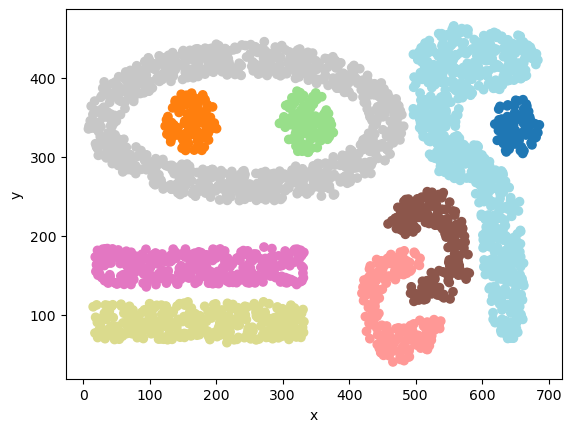

In [6]:
atr_x = "x"
atr_y= "y"
plt.scatter(df[atr_x], df[atr_y], c=df["class"], cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

In [5]:
# Se eliminan atributos categóricos. Pero antes se guardan todos los datos en df_0

df_0 = df.copy()
#df_0['class']=df['class'].str.decode("utf-8")

df = df.drop(["class"], axis=1)

In [6]:
# Normalizar los datos

df = (df-df.min())/(df.max()-df.min())

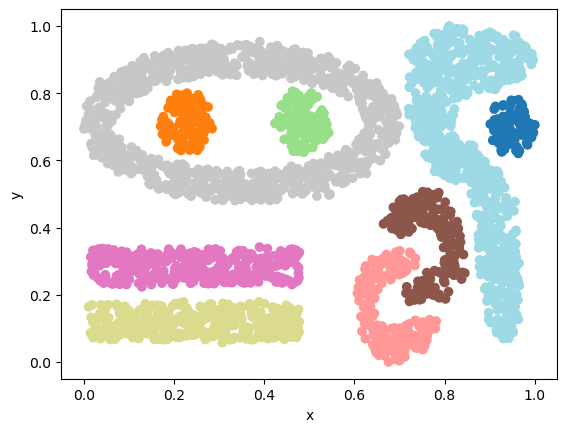

In [7]:
atr_x = "x"
atr_y= "y"
plt.scatter(df[atr_x], df[atr_y], c=df_0['class'], cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

In [8]:
# Obtener matriz de enlazado

linkm = linkage(df, method='single')

In [9]:
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

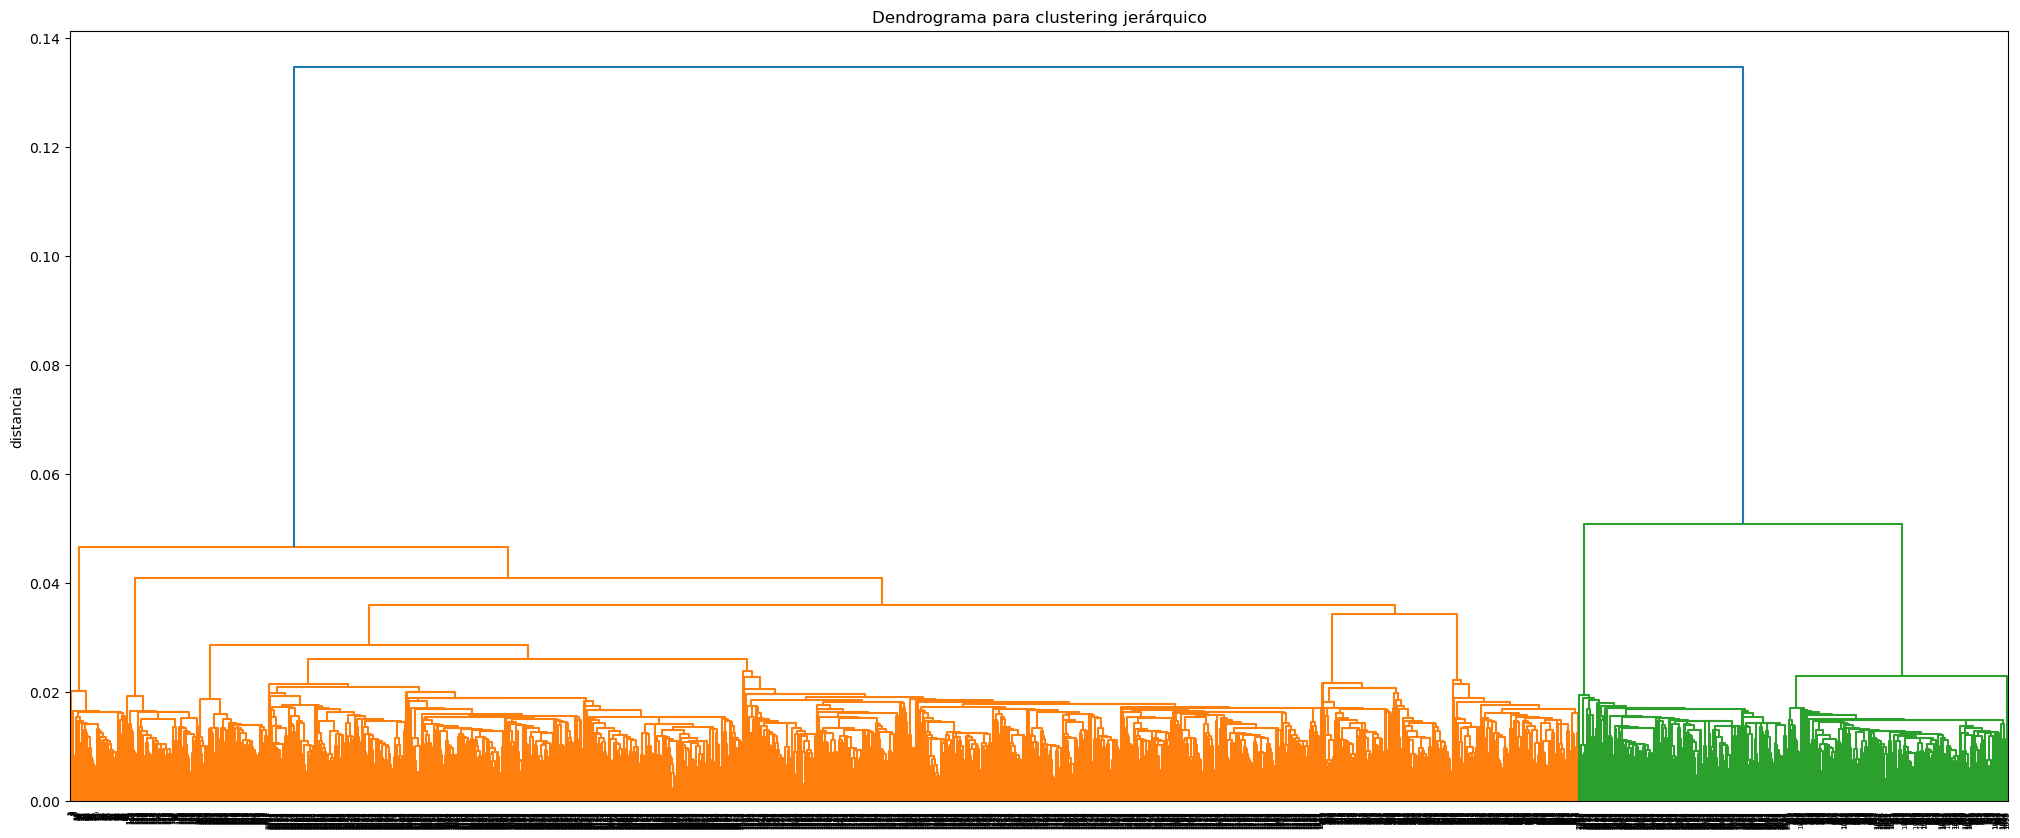

In [10]:
# Dendrograma

plt.figure(figsize=(25,10))
plt.title('Dendrograma para clustering jerárquico')
plt.ylabel('distancia')
dendrogram(
    linkm,
#    leaf_rotation=90.,  # Rotación etiquetas en eje x
#    leaf_font_size=8.,  # Tamaño de fuente etiquetas eje x
)
plt.show()

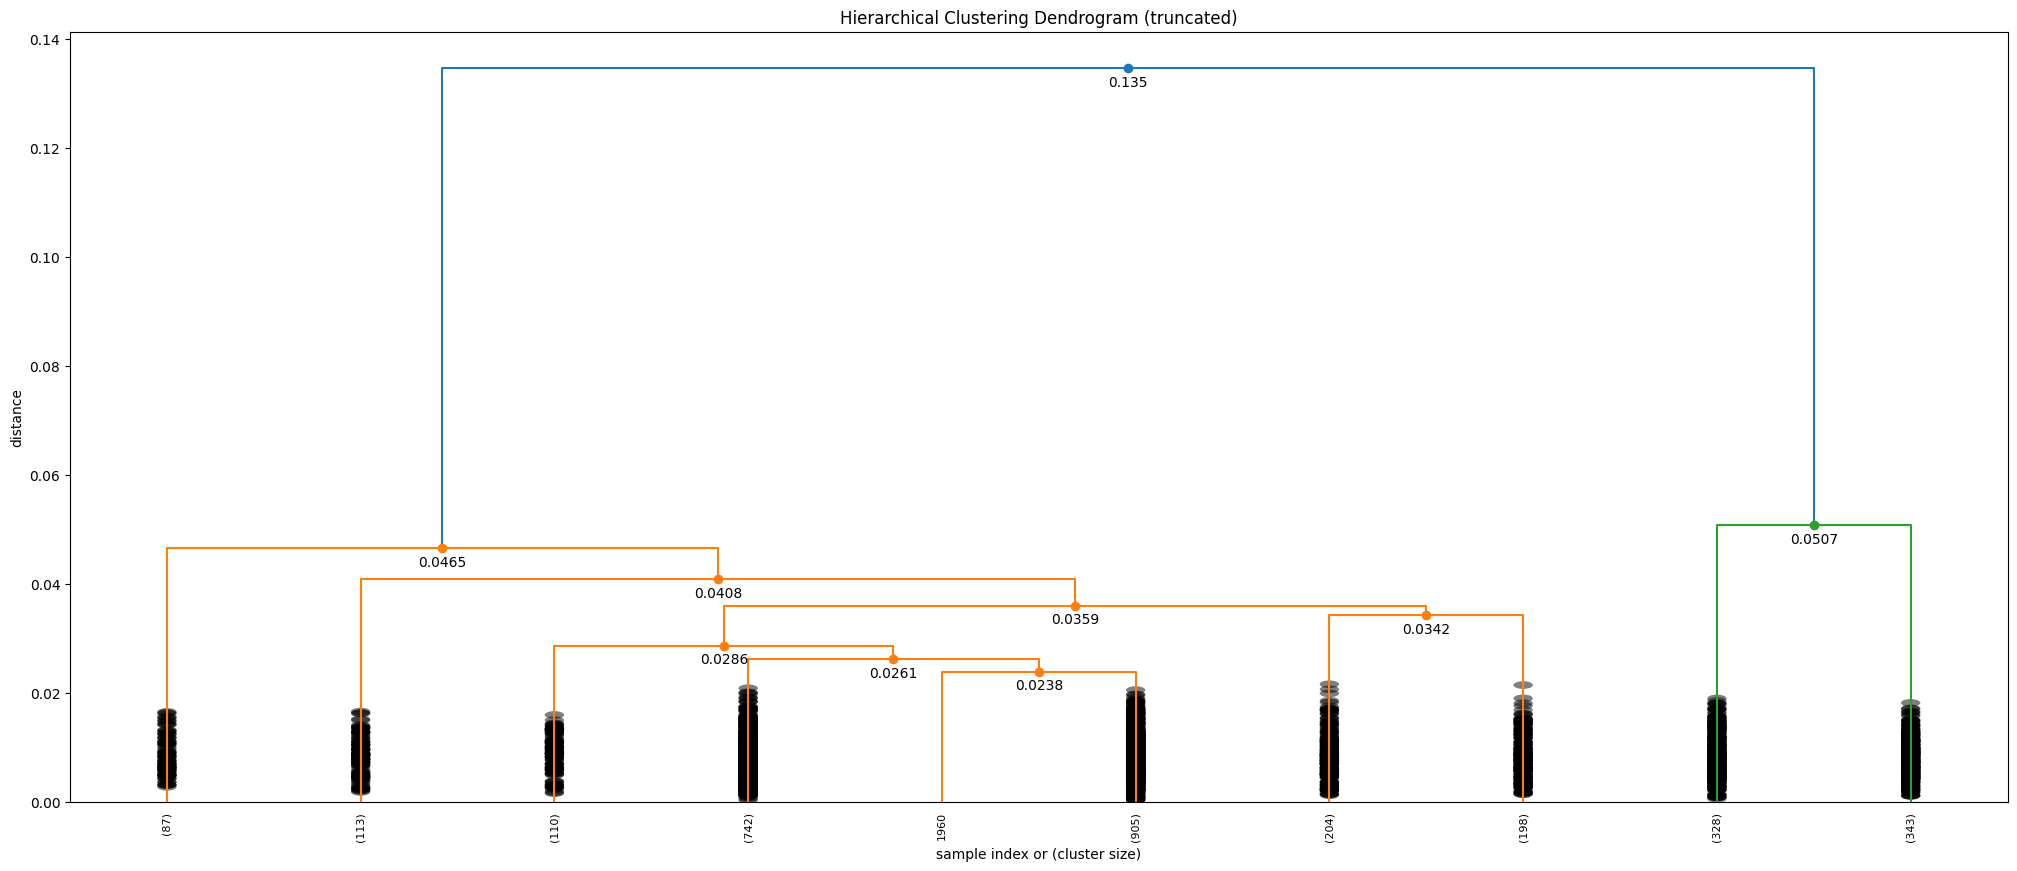

In [ ]:
# Dendrograma truncado, con 10 clusters, por ejemplo

plt.figure(figsize=(25,10))
plt.title('Dendrograma truncado')
plt.xlabel('índice de observación')
plt.ylabel('distancia')
fancy_dendrogram(
    linkm,
    truncate_mode = 'lastp',  # Muestra solo los p últimos clusters fusionados
    p=10,
    show_leaf_counts = True,  # Números muestran índice de la observación, o cuenta de observaciones si en paréntesis.
    leaf_rotation=90.,  # Rotación etiquetas en eje x
    leaf_font_size=8.,  # Tamaño de fuente etiquetas eje x
    show_contracted=True
)
plt.show()

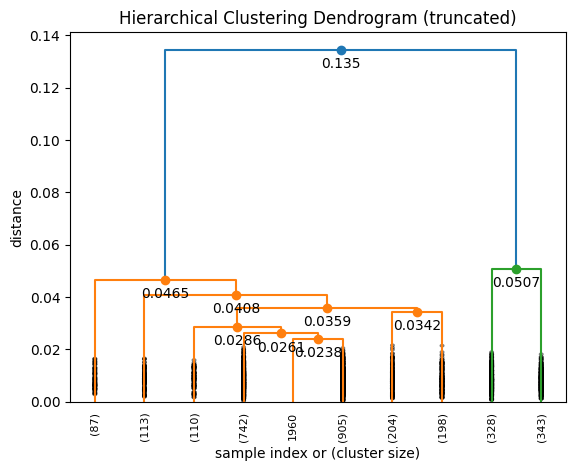

In [ ]:
fancy_dendrogram(
    linkm,
    truncate_mode='lastp',
    p=10,
    show_leaf_counts = True,  # Números muestran índice de la observación, o cuenta de observaciones si en paréntesis.
    leaf_rotation=90.,  # Rotación etiquetas en eje x
    leaf_font_size=8.,  # Tamaño de fuente etiquetas eje x
    show_contracted=True
)
plt.show()

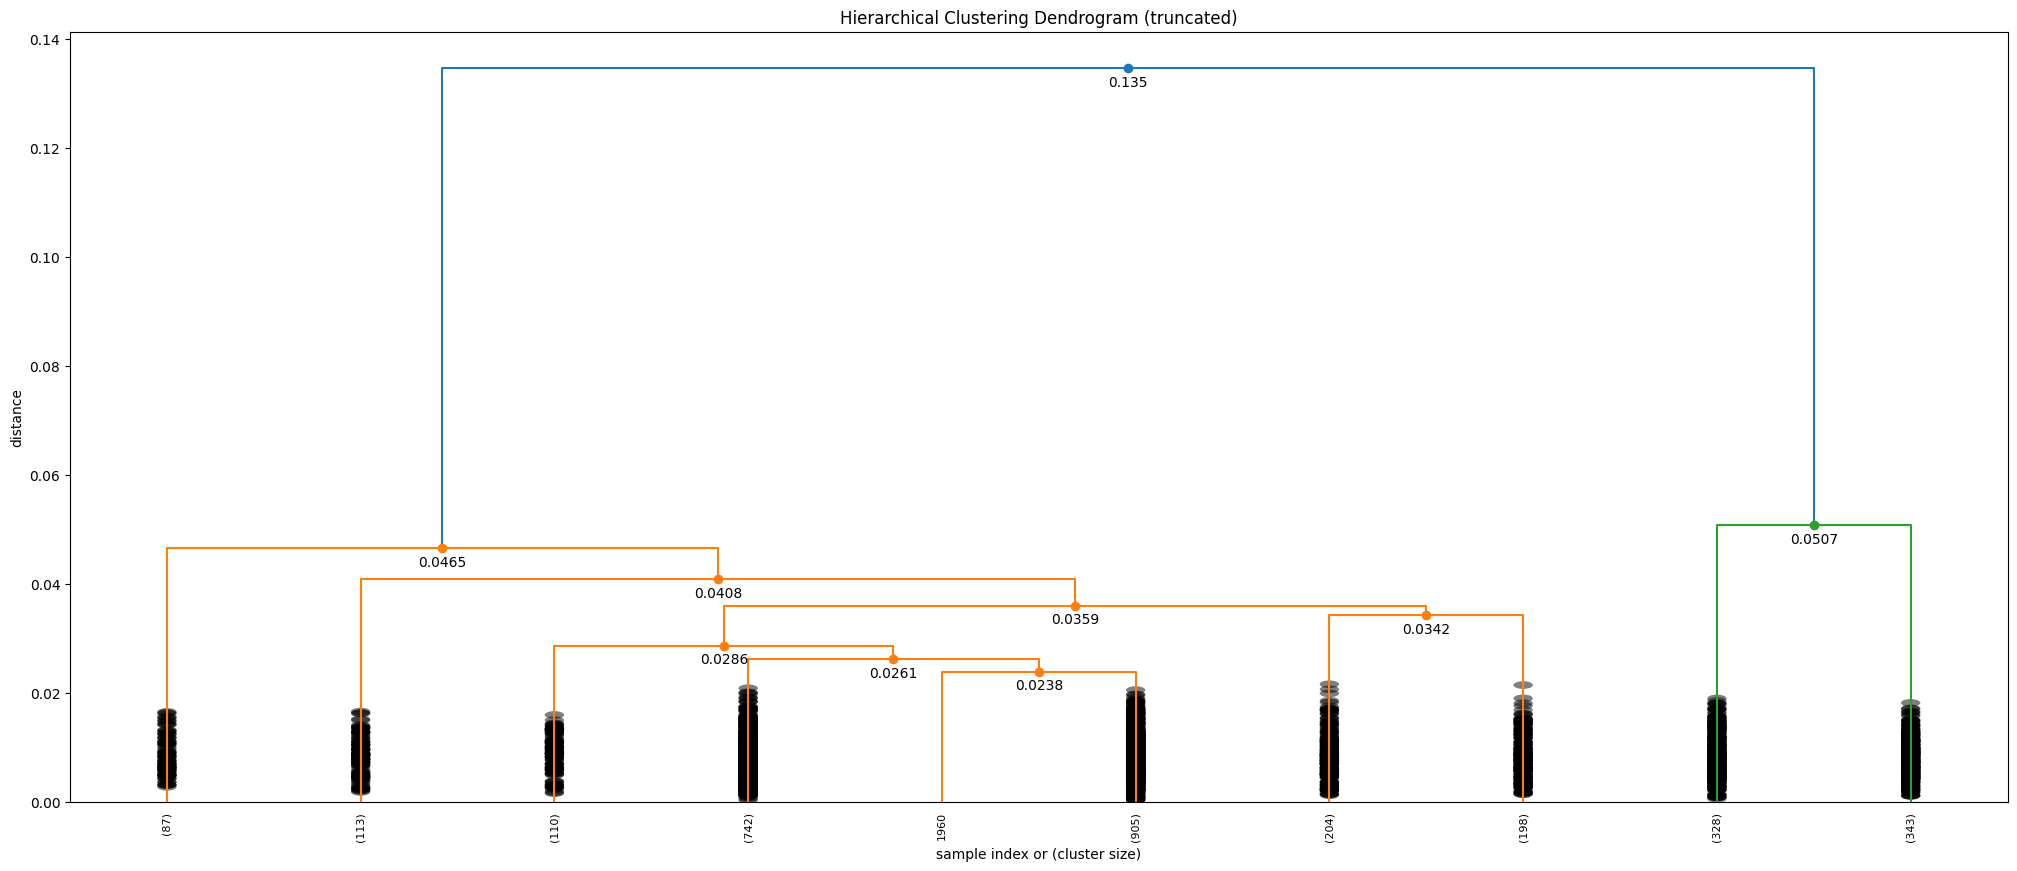

In [ ]:
plt.figure(figsize=(25,10))
plt.title('Dendrograma truncado')
plt.xlabel('índice de observación')
plt.ylabel('distancia')
fancy_dendrogram(
    linkm,
    truncate_mode = 'lastp',  # Muestra solo los p últimos clusters fusionados
    p=10,
    show_leaf_counts = True,  # Números muestran índice de la observación, o cuenta de observaciones si en paréntesis.
    leaf_rotation=90.,  # Rotación etiquetas en eje x
    leaf_font_size=8.,  # Tamaño de fuente etiquetas eje x
    show_contracted=True
)
plt.show()

In [11]:
# Obtener los clusters

# Por distancia máxima entre puntos de un mismo cluster

max_d = 0.0238

clusters = fcluster(linkm, max_d, criterion='distance')

Número de clusters: 10


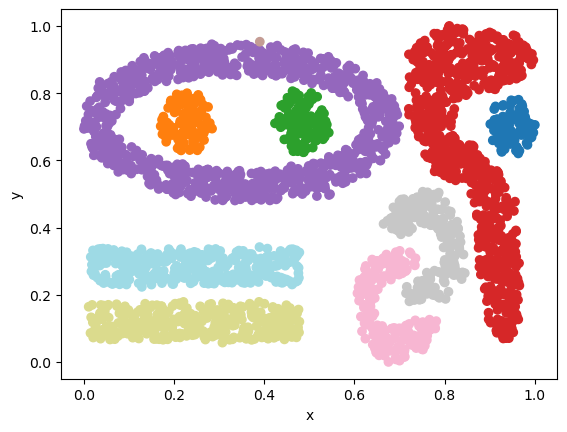

In [12]:
# Dibujar los clusters

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Número de clusters: %d" % n_clusters)

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

Número de clusters: 22


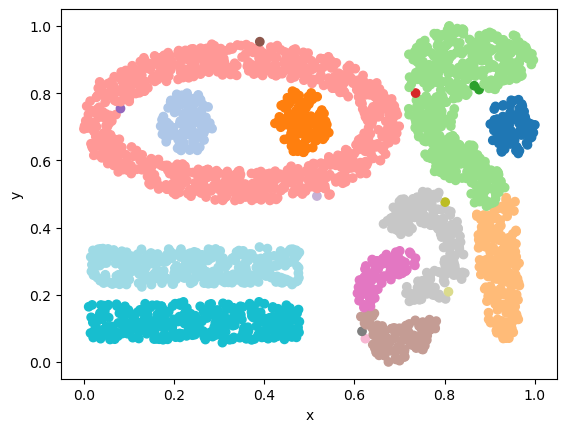

In [13]:
# Probar con distancia máxima mayor entre puntos de un mismo cluster

max_d = 0.02

clusters = fcluster(linkm, max_d, criterion='distance')

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Número de clusters: %d" % n_clusters)

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

Número de clusters: 7


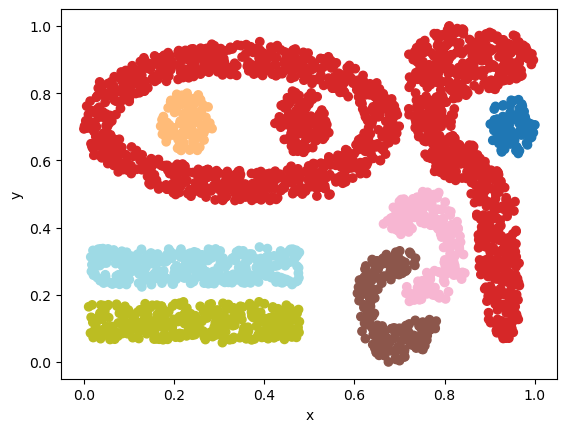

In [14]:
# Probar con distancia máxima mayor entre puntos de un mismo cluster

max_d = 0.03

clusters = fcluster(linkm, max_d, criterion='distance')

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Número de clusters: %d" % n_clusters)

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

Número de clusters: 9


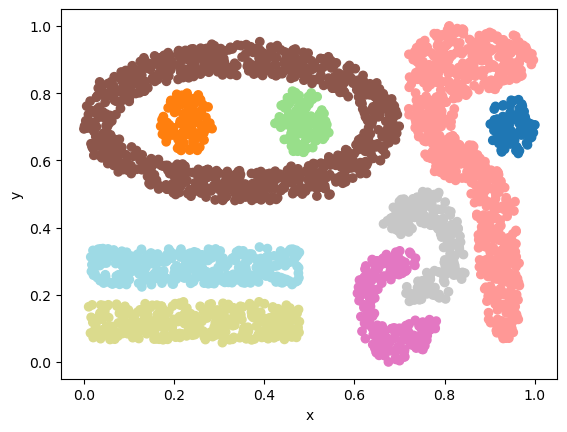

In [15]:
# Probar con distancia máxima mayor entre puntos de un mismo cluster

max_d = 0.025

clusters = fcluster(linkm, max_d, criterion='distance')

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Número de clusters: %d" % n_clusters)

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

In [16]:
# Métricas

# Algunas se calculan con respecto al valor correcto de las etiquetas. Pero scikit-learn
# requiere que tengan valor numérico.

# Codificación de etiquetas correctas (atributo class) como valores numéricos

le = preprocessing.LabelEncoder()
le.fit(df_0["class"])
df["true_label"] = le.transform(df_0["class"])

In [17]:


# Se considera que un valor -1 para la etiqueta significa que es ruido.
# No es el caso aquí, pero sí con la implementación de DBSCAN de Scikit-learn

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("Número de clusters: %d" % n_clusters)

#n_outliers = list(clusters).count(-1)
#print("Outliers: %d" % n_outliers)

print("Coeficiente de silueta: %0.3f" % metrics.silhouette_score(df[[atr_x,atr_y]], clusters))

print("Homogeneidad: %0.3f" % metrics.homogeneity_score(df["true_label"], clusters))
print("Completitud: %0.3f" % metrics.completeness_score(df["true_label"], clusters))
print("Medida V: %0.3f" % metrics.v_measure_score(df["true_label"], clusters))
print("Índice de Rand ajustado (ARI): %0.3f" % metrics.adjusted_rand_score(df["true_label"], clusters))
print("MI ajustado (AMI): %0.3f" % metrics.adjusted_mutual_info_score(df["true_label"], clusters))


Número de clusters: 9
Coeficiente de silueta: -0.013
Homogeneidad: 1.000
Completitud: 1.000
Medida V: 1.000
Índice de Rand ajustado (ARI): 1.000
MI ajustado (AMI): 1.000


{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [55.0, 55.0, 65.0, 65.0],
  [32.5, 32.5, 60.0, 60.0],
  [15.0, 15.0, 46.25, 46.25],
  [5.0, 5.0, 30.625, 30.625],
  [75.0, 75.0, 85.0, 85.0],
  [17.8125, 17.8125, 80.0, 80.0]],
 'dcoord': [[0.0,
   np.float64(0.02608450748037314),
   np.float64(0.02608450748037314),
   0.0],
  [0.0,
   np.float64(0.028610519742559327),
   np.float64(0.028610519742559327),
   np.float64(0.02608450748037314)],
  [0.0, np.float64(0.03420096290561364), np.float64(0.03420096290561364), 0.0],
  [np.float64(0.028610519742559327),
   np.float64(0.03592235128239446),
   np.float64(0.03592235128239446),
   np.float64(0.03420096290561364)],
  [0.0,
   np.float64(0.04082729790995452),
   np.float64(0.04082729790995452),
   np.float64(0.03592235128239446)],
  [0.0,
   np.float64(0.0465032612792155),
   np.float64(0.0465032612792155),
   np.float64(0.04082729790995452)],
  [0.0,
   np.float64(0.050690778223715496),
   np.float64(0.050690778223715496

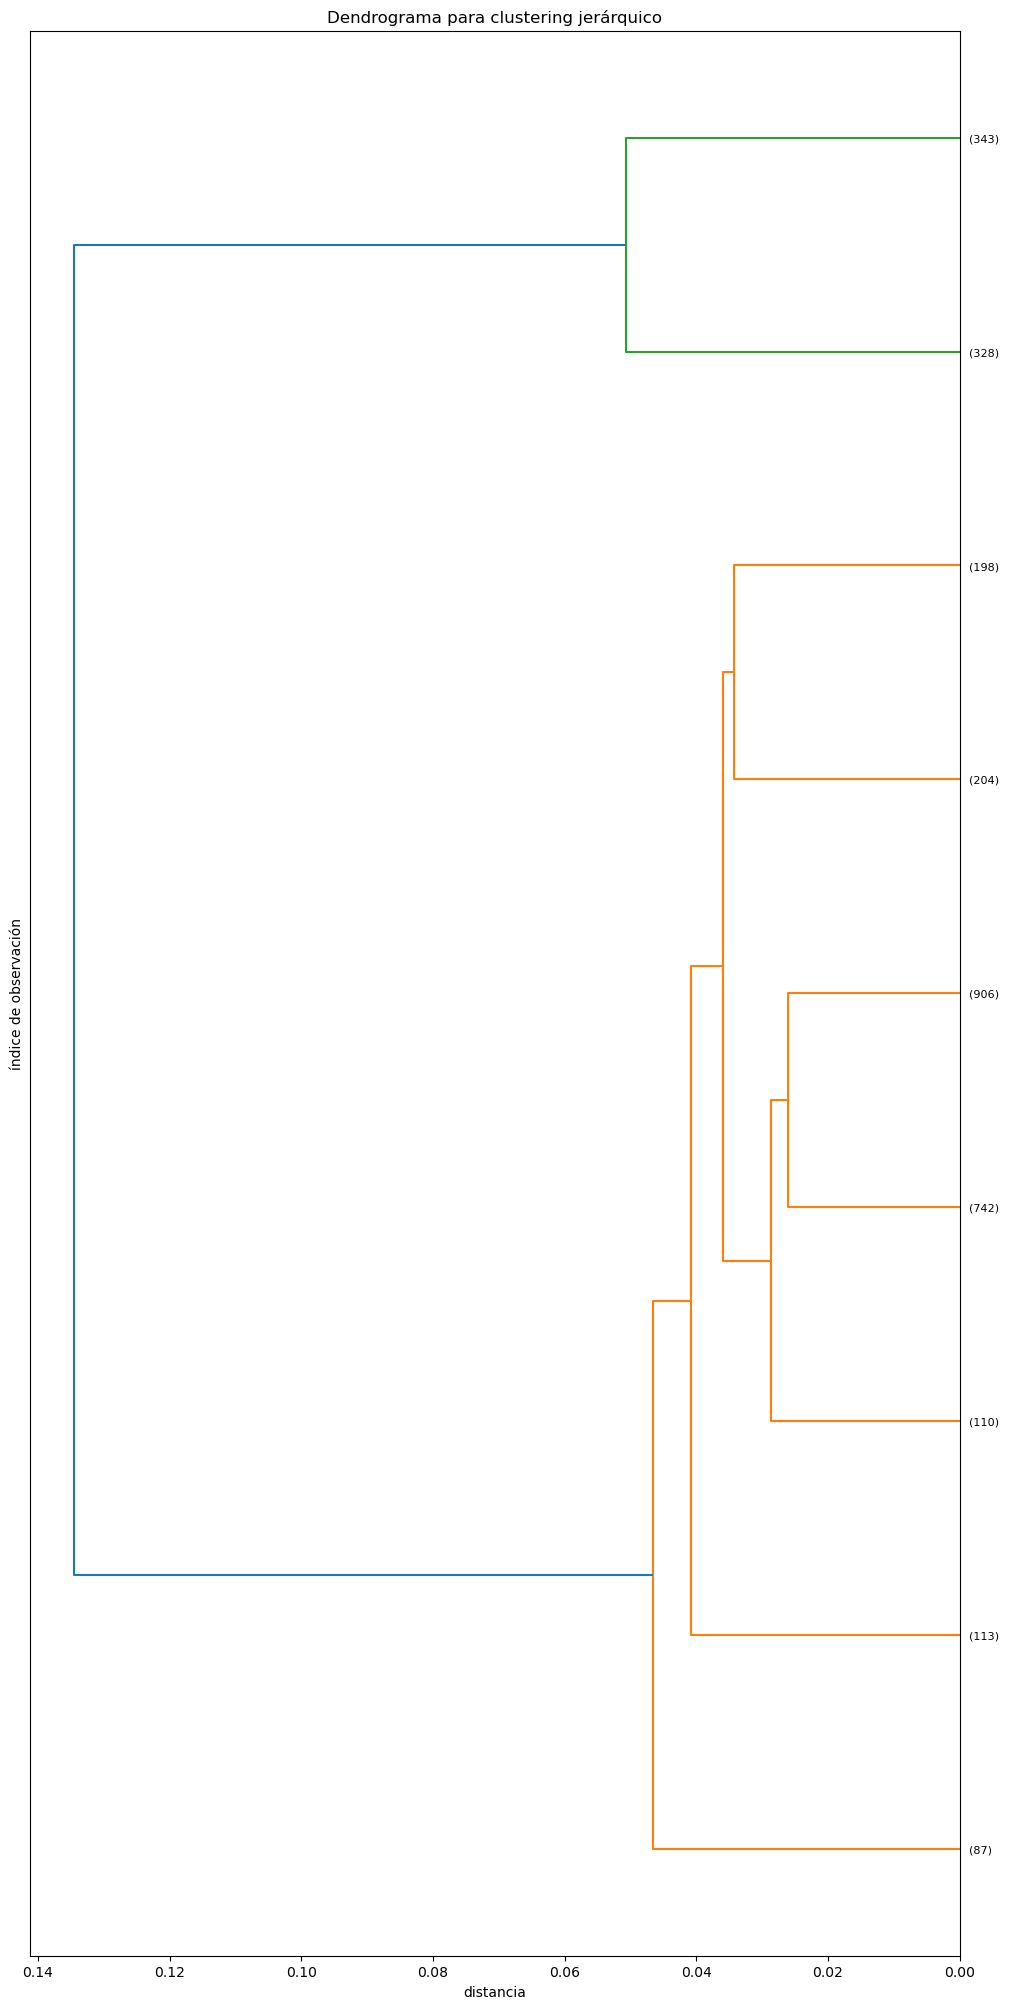

In [18]:
# Son 9 clusters

n_clusters = 9

# Dibujar dendrograma con etiquetas

plt.figure(figsize=(12,25))

# Primero no se dibuja (no_plot=True)

plt.title('Dendrograma para clustering jerárquico')
plt.xlabel('distancia')
plt.ylabel('índice de observación')
L=dendrogram(
    linkm,
    truncate_mode = 'lastp',  # Muestra solo los p últimos clusters fusionados
    p=n_clusters,
    get_leaves = True,
    orientation = 'left',
    no_plot = True
)

#def llf(ind):
#  if ind < df_0.shape[0]:
#    return df_0.iloc[ind]["class"]
#  else:
#    return "_"

plt.title('Dendrograma para clustering jerárquico')
plt.xlabel('distancia')
plt.ylabel('índice de observación')
dendrogram(
    linkm,
    truncate_mode = 'lastp',  # Muestra solo los p últimos clusters fusionados
    p=n_clusters,
    get_leaves = True,
    orientation = 'left',
    leaf_rotation=0.,  # Rotación etiquetas
    leaf_font_size=8.,  # Tamaño de fuente etiquetas eje x
#    leaf_label_func = llf
)


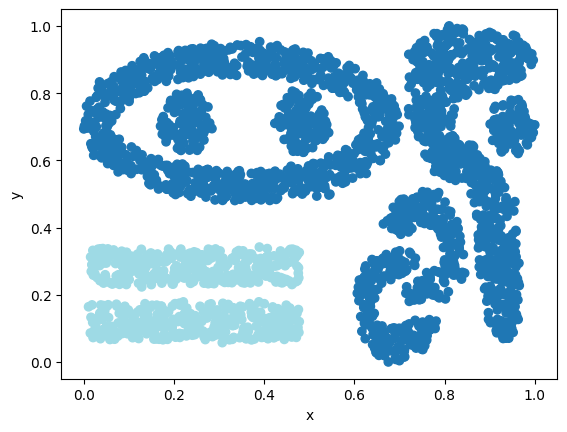

In [ ]:
# También se pueden seleccionar los clusters estableciendo un número de clusters

n_clust = 2
clusters = fcluster(linkm, n_clust, criterion='maxclust')

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

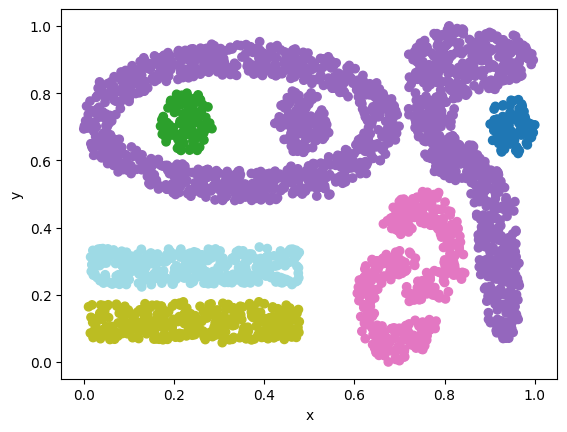

In [ ]:
n_clust = 6
clusters = fcluster(linkm, n_clust, criterion='maxclust')

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

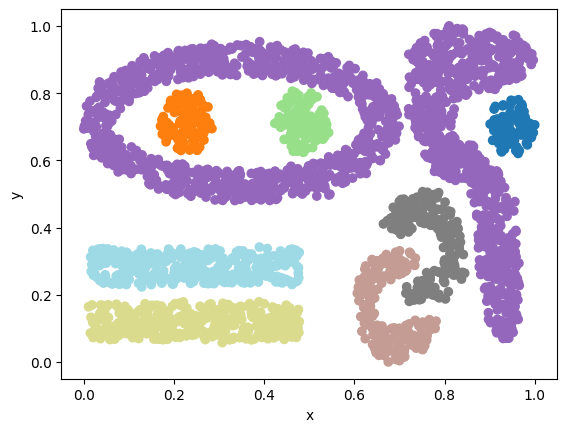

In [ ]:
n_clust = 8
clusters = fcluster(linkm, n_clust, criterion='maxclust')

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

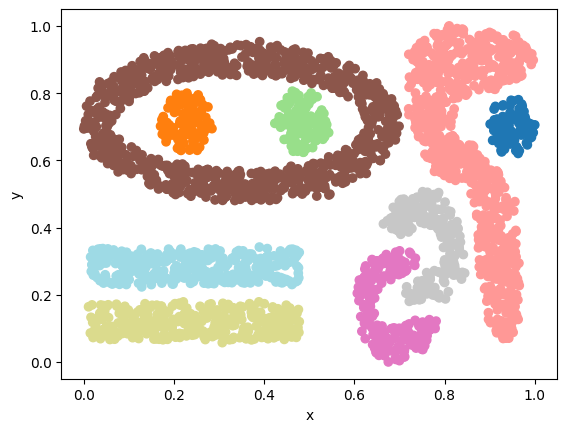

In [ ]:
n_clust = 9
clusters = fcluster(linkm, n_clust, criterion='maxclust')

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()

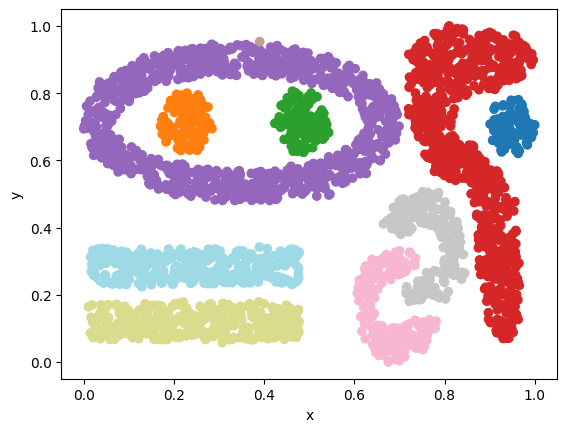

In [ ]:
n_clust = 10
clusters = fcluster(linkm, n_clust, criterion='maxclust')

plt.scatter(df[atr_x], df[atr_y], c=clusters, cmap="tab20")
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()